In [3]:
import pandas as pd
import numpy as np
df = pd.read_csv('todays_data.csv')
print(df)

    First Name  Country      Gender Academic Level
0    abdikhafar   Kenya        male  UnderGraduate
1           plp   Kenya  non_binary            NaN
2      milicent   Kenya      female  UnderGraduate
3      jeremiah   Kenya        male  UnderGraduate
4          emma   Kenya      female        Diploma
..          ...     ...         ...            ...
348      curtis   Kenya        male      secondary
349      lameck   Kenya        male     HighSchool
350    anderson   Kenya        male            NaN
351      hedmon   Kenya        male  UnderGraduate
352     bernard   Kenya        male        Diploma

[353 rows x 4 columns]


In [2]:
df.head()

,First Name,Country,Gender,Academic Level
0,abdikhafar,Kenya,male,UnderGraduate
1,plp,Kenya,non_binary,NaN
2,milicent,Kenya,female,UnderGraduate
3,jeremiah,Kenya,male,UnderGraduate
4,emma,Kenya,female,Diploma


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 353 entries, 0 to 352
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   First Name      353 non-null    object
 1   Country         353 non-null    object
 2   Gender          353 non-null    object
 3   Academic Level  350 non-null    object
dtypes: object(4)
memory usage: 11.2+ KB


In [4]:
df.isnull().sum()

First Name        0
Country           0
Gender            0
Academic Level    3
dtype: int64

In [8]:
df["Academic Level"].fillna('Unknown', inplace=True)

In [7]:
print(df.describe())

       First Name  Country Gender Academic Level
count          350     350    350            350
unique         257       1      2              8
top          brian   Kenya   male  UnderGraduate
freq             7     350    257            204


In [9]:
print(df['Gender'].value_counts())

Gender
male      257
female     93
Name: count, dtype: int64


In [10]:
print(df['Academic Level'].value_counts())

Academic Level
UnderGraduate    204
HighSchool        52
undergraduate     34
Diploma           33
secondary         15
diploma            7
PostGraduate       4
other              1
Name: count, dtype: int64


In [11]:
gender_group = df.groupby('Gender').size()
print(gender_group)

Gender
female     93
male      257
dtype: int64


In [12]:
academic_level_group = df.groupby('Academic Level').size()
print(academic_level_group)

Academic Level
Diploma           33
HighSchool        52
PostGraduate       4
UnderGraduate    204
diploma            7
other              1
secondary         15
undergraduate     34
dtype: int64


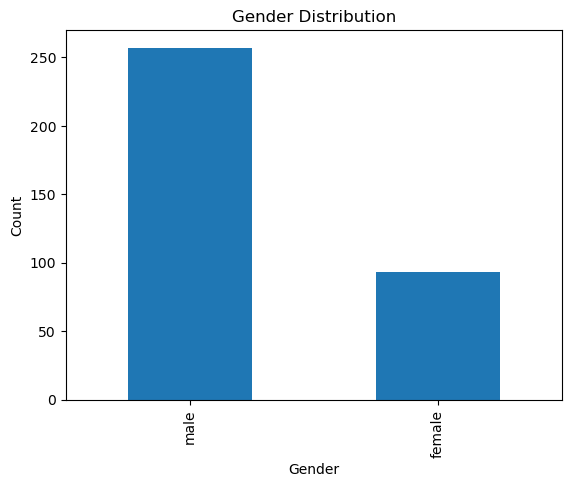

In [13]:
import matplotlib.pyplot as plt

#Bar chart for gender 
df['Gender'].value_counts().plot(kind='bar')
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

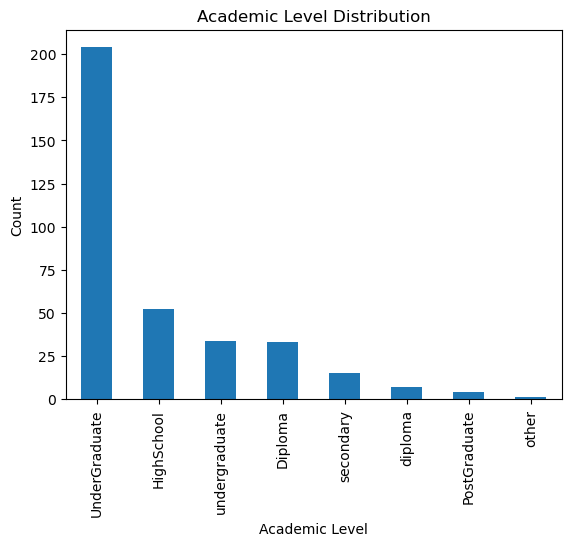

In [14]:
#Bar chart for Academic levels
df['Academic Level'].value_counts().plot(kind='bar')
plt.title('Academic Level Distribution')
plt.xlabel('Academic Level')
plt.ylabel('Count')
plt.show()

In [4]:
import numpy as np

np.random.seed(42)

df['Age'] = np.random.randint(18, 36, size=len(df))
print(df.describe())

              Age
count  353.000000
mean    25.954674
std      5.386029
min     18.000000
25%     21.000000
50%     25.000000
75%     31.000000
max     35.000000


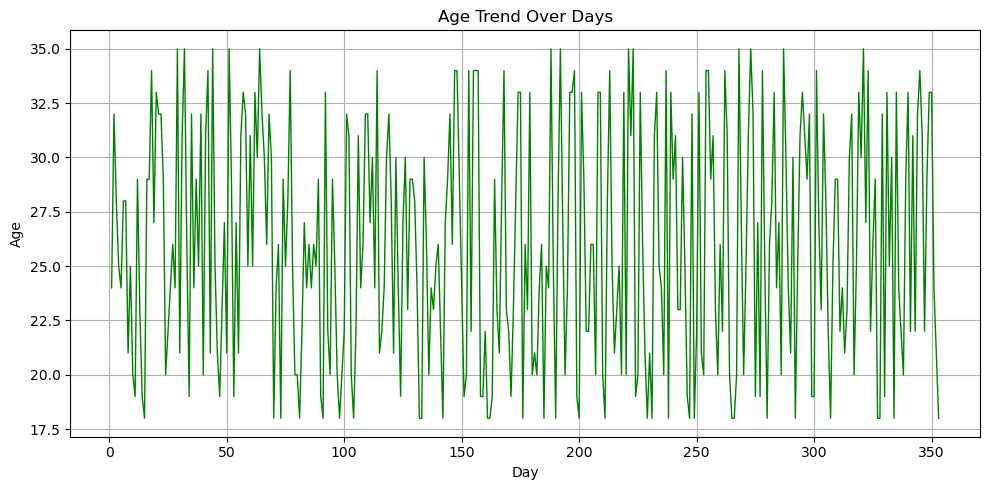

In [6]:
#Line chart with made up data 
import matplotlib.pyplot as plt

#Create a time like index
df['Day'] = range(1, len(df) + 1)

#Plot a line chart - Age over Days
plt.figure(figsize=(10, 5))
plt.plot(df['Day'], df['Age'], color='green', linestyle='-', linewidth=1)

#Chart
plt.title('Age Trend Over Days')
plt.xlabel('Day')
plt.ylabel('Age')
plt.grid(True)
plt.tight_layout()
plt.show()


In [7]:
#Create numeric codes for Academic Level
df['AcademicCode'] = df['Academic Level'].astype('category').cat.codes


ValueError: The number of FixedLocator locations (9), usually from a call to set_ticks, does not match the number of labels (8).

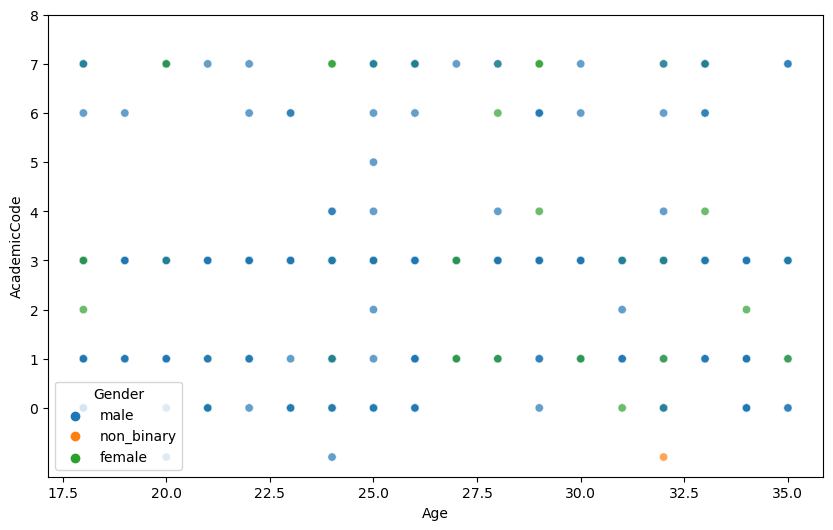

In [13]:
#Create the Scatter plot
import seaborn as sns
import matplotlib.pyplot as plt

#For consistency, creating category object
df['Academic Level'] = df['Academic Level'].astype('category')
df['AcademicCode'] = df['Academic Level'].cat.codes

plt.figure(figsize=(10, 6))

#Scatter plot with Age vs Academic Level (as codes)
sns.scatterplot(data=df, x='Age', y='AcademicCode', hue='Gender', alpha=0.7)

#Customize the y-axis and labels properly
plt.yticks(
    ticks=range(df['AcademicCode'].nunique()),
    labels=df['Academic Level'].astype('category').cat.categories
)
    
#Create chart
plt.title('Scatter Plot: Age vs Academic Level')
plt.xlabel('Age')
plt.ylabel('Academic Level (Encoded)')
plt.grid(True)
plt.tight_layout()
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

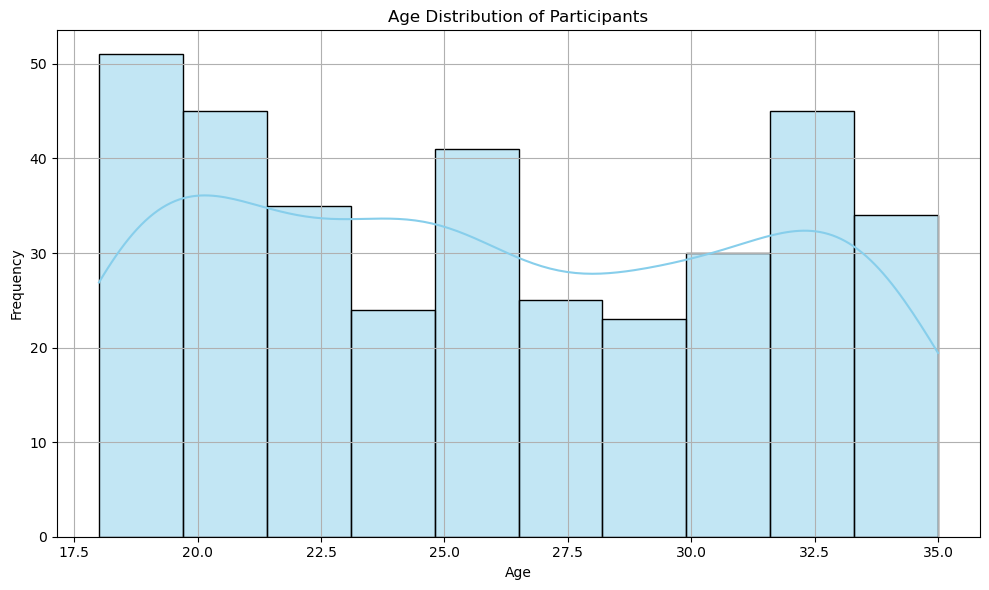

In [16]:
#Histogram showing distribution of Age
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Age', bins=10, kde=True, color='skyblue')

plt.title('Age Distribution of Participants')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show